In [1]:
import sys
import importlib.util
import os
module_path = os.path.join(os.getcwd(), "markov_model.py")
spec = importlib.util.spec_from_file_location("markov_model", module_path)
markov_model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(markov_model)
synthetic = markov_model.generate_synthetic_load(
    monthly_kwh=350,
    days=30,
    random_seed=42
)
synthetic[:24]  # first day

C:\Users\bhara\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ Markov transition matrix saved


AttributeError: module 'markov_model' has no attribute 'generate_synthetic_load'

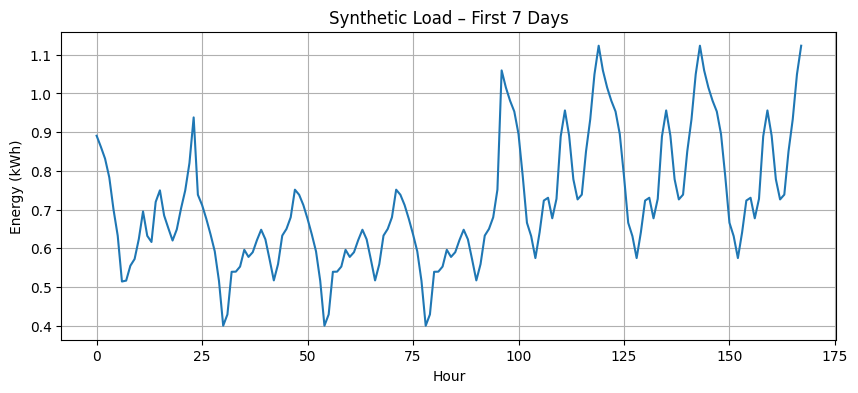

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(synthetic[:168])
plt.title("Synthetic Load – First 7 Days")
plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.grid()
plt.show()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load actual hourly data
actual_df = pd.read_csv("../outputs/cleaned_hourly.csv")
actual_load = actual_df["t_kWh"].values

print("Actual load samples:", actual_load[:10])
print("Total actual hours:", len(actual_load))


Actual load samples: [ 5.393  4.623  4.189  4.234  4.56   4.633  4.291  5.787 11.787 20.835]
Total actual hours: 7296


In [3]:
from markov_model import generate_synthetic_load

# Estimate monthly consumption from actual data
hours_per_month = 24 * 30
monthly_kwh = actual_load[:hours_per_month].sum()

synthetic_load = generate_synthetic_load(
    monthly_kwh=monthly_kwh,
    days=len(actual_load)//24,
    random_seed=42
)

# Align lengths
min_len = min(len(actual_load), len(synthetic_load))
actual_load = actual_load[:min_len]
synthetic_load = synthetic_load[:min_len]

print("Synthetic load samples:", synthetic_load[:10])


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\bhara\\Desktop\\Capstone\\IEMS\\synthetic_load\\synthetic_load/kmeans_model.pkl'

NameError: name 'synthetic_load' is not defined

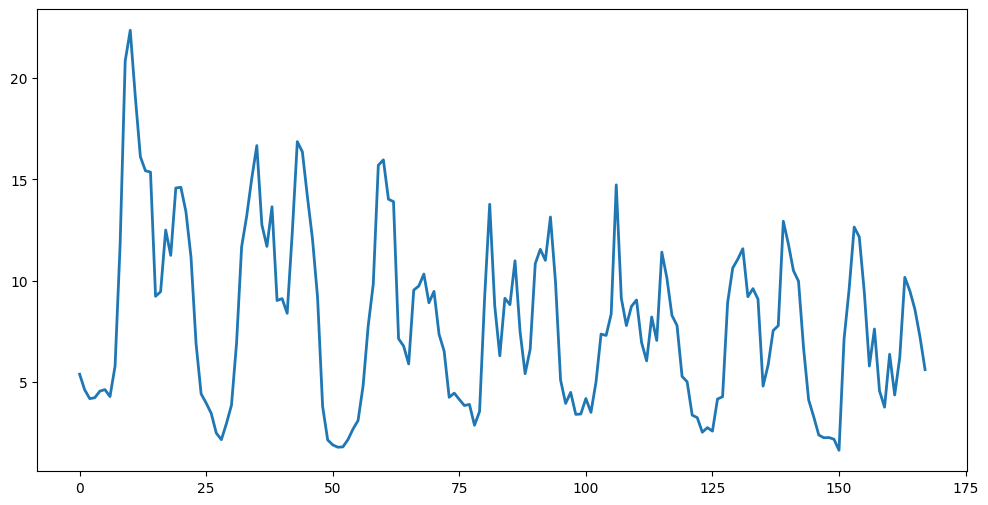

In [4]:
hours = 24 * 7  # 7 days

plt.figure(figsize=(12,6))
plt.plot(actual_load[:hours], label="Actual Load", linewidth=2)
plt.plot(synthetic_load[:hours], label="Synthetic (Predicted) Load", linestyle="--")

plt.xlabel("Hour")
plt.ylabel("Energy (kWh)")
plt.title("Actual vs Synthetic Load (First 7 Days)")
plt.legend()
plt.grid(True)
plt.show()


In [1]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

mape = mean_absolute_percentage_error(actual_load, synthetic_load) * 100
rmse = np.sqrt(mean_squared_error(actual_load, synthetic_load))

print(f"MAPE : {mape:.2f} %")
print(f"RMSE : {rmse:.3f} kWh")


NameError: name 'actual_load' is not defined

In [ ]:
import matplotlib.pyplot as plt

error = np.abs(actual_load - synthetic_load)

plt.figure(figsize=(12,5))
plt.plot(actual_load, label="Actual Load")
plt.plot(synthetic_load, linestyle="--", label="Synthetic Load")
plt.fill_between(
    range(len(actual_load)),
    synthetic_load - error,
    synthetic_load + error,
    alpha=0.2,
    label="Error Margin"
)

plt.legend()
plt.xlabel("Hour")
plt.ylabel("kWh")
plt.title("Actual vs Synthetic Load (Hourly Markov)")
plt.show()
